# CSC 411: Timed Machine Learning Practical
## Starter Notebook. Breast Cancer: Malignant or Benign?

| | |
|---|---|
| **Task** | Binary classification. Predict whether a tumour is malignant or benign |
| **Duration** | 3 hours |
| **Scoring Metric** | F1 Score (macro) |
| **Baseline Score** | ≈ 0.50 → 10% |
| **Max Submissions** | 10 |
| **Submit** | `submission_{n}.csv` + this notebook (`.ipynb`) |


### Grading Breakdown

| Component | Weight |
|||
| Benchmark Performance (F1 score) | 15 marks |
| Notebook Quality (EDA, features, models, commentary) | 15 marks |
| Total | 30 marks |

**Benchmark scale:**
For this lab, the metric used is F1 score. Here's the breakdown for the benchmark performance:

| Score | Marks (out of 15) |
|---|---|
|0.50–0.55 | 1.5 |
|0.56–0.60 | 3 |
|0.61–0.65 | 4.5 |
|0.66–0.70 | 7.5 |
|0.71–0.75 | 9 |
|0.76–0.80 | 10.5 |
|0.81–0.85 | 12 |
|0.86–0.90 | 14 |
|0.91–1.00 | 15 |

### ⏱️ Suggested Time Plan

| Time | Activity |
|---|---|
| 0:00 – 0:20 | **Run this notebook end-to-end. Make your first submission (baseline).** |
| 0:20 – 0:50 | Explore the data, understand who survived and why. |
| 0:50 – 1:40 | Feature engineering + try multiple models. Submit best. |
| 1:40 – 2:20 | Hyperparameter tuning. Re-submit. |
| 2:20 – 2:50 | Polish notebook: add markdown commentary on every decision. |
| 2:50 – 3:00 | Final submission check. |


> **Rule of thumb:** A submitted baseline beats an unsubmitted perfect model. Get something on the board first.

### ⚠️ Instructions
1. Do **not** rename or delete this notebook. Extend it: `starter_notebook_{firstname}_{lastname}.ipynb`. E.g `starter_notebook_Bunmi_Akinremi.ipynb`
2. The **Appendix** at the bottom is your offline reference: all the sklearn documentation you need. Since this is a practice notebook, try to see if you can complete the tasks using only the information in the Appendix. You can also use help() function to provide more information about a function or method. E.g help(LogisticRegression)
3. Add **markdown cells** to explain every significant decision (model choice, feature rationale, hyperparameter changes). This is worth 20% of your mark.
4. Your submitted notebook will be reviewed for academic integrity.

## ⚠️ Important
1. Do not delete/change the cell with this code: `test_ids = test_df[ID_COL].copy()`. You will not be able to make a submission without it

### Submission Instructions
1. After running the notebook up to section 4, you'd see a new file generated for you. By default it is named `submission_01.csv`. This file along with the saved version of this notebook should be submitted to the e-learning platform.
2. Section 5 and 6 contain ready made ideas on how to improve the model performance. For simplicity, you can copy certain parts of your code and move them in between Section 0 and Section 4.
3. Appendix shows models avaliable for you to use. It also gives code snippet on how to use them. A you can simply lift and use the models in your work. If you use external models, be sure to explain why. 


## Section 0: Setup: Run This First

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white', 'font.size': 11})
sns.set_palette('husl')

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV, RandomizedSearchCV
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

SEED = 42
np.random.seed(SEED)
print("All libraries loaded.")

All libraries loaded.



## Section 1: Data Loading

The exam dataset is pre-loaded on your machine.

- **`train.csv`**: labelled tumour samples with a known `target` column
- **`test.csv`**: unlabelled samples; you must predict their `target`

**Target encoding:** 0 = Malignant (cancerous), 1 = Benign (non-cancerous)

**Column descriptions:**

| Column | Description |
|---|---|
| `id` | Patient sample ID: not a feature |
| `target` | **Target**: 0 = malignant, 1 = benign |
| `mean_radius` | Mean distance from cell centre to perimeter |
| `mean_texture` | Standard deviation of grey-scale values |
| `mean_perimeter` | Mean perimeter of the cell nucleus |
| `mean_area` | Mean area of the cell nucleus |
| `mean_smoothness` | Mean local variation in radius lengths |
| `mean_compactness` | Mean of (perimeter² / area − 1.0) |
| `mean_concavity` | Mean severity of concave portions of the contour |
| `mean_concave_points` | Mean number of concave portions |
| `mean_symmetry` | Mean symmetry of the nucleus |
| `mean_fractal_dimension` | Mean "coastline approximation" − 1 |
| `*_error` | Standard error of the above 10 measurements |
| `worst_*` | Largest (worst) value of the above 10 measurements |

> There are **30 numeric features** in total: 10 measurements × 3 statistics (mean, error, worst).
> There are **no missing values** in this dataset.

In [ ]:
TARGET = 'target'
ID_COL = 'id'

#  Load data 
# The files are pre-loaded in the data/ folder on your machine.
try:
    train_df = pd.read_csv('data/train.csv')
    test_df  = pd.read_csv('data/test.csv')
    print("Loaded from data/ folder.")
except FileNotFoundError:
    # Fallback: reconstruct from sklearn (for practice outside the exam)
    print("data/ not found: using sklearn breast cancer dataset as fallback.")
    from sklearn.datasets import load_breast_cancer
    bc   = load_breast_cancer()
    cols = [n.replace(' ', '_') for n in bc.feature_names]  # e.g. 'mean_radius'
    df   = pd.DataFrame(bc.data, columns=cols)
    df['target'] = bc.target   # 0 = malignant, 1 = benign
    df.insert(0, ID_COL, range(1, len(df) + 1))
    _train, _test = train_test_split(df, test_size=0.2, stratify=df['target'], random_state=SEED)
    train_df = _train.reset_index(drop=True)
    test_df  = _test.drop(columns=['target']).reset_index(drop=True)

## ⚠️ Important
Do not delete the cell below! You will not be able to create a submission file if you remove `test_ids`.

In [9]:
# Save sample IDs for the submission file
test_ids = test_df[ID_COL].copy()

In [10]:
print(f"Train : {train_df.shape}  |  Test : {test_df.shape}")
print(f"\nDiagnosis distribution in training set:")
print(train_df[TARGET].value_counts().rename({0: 'Malignant (0)', 1: 'Benign (1)'}).to_string())
print(f"Malignant rate : {(train_df[TARGET] == 0).mean():.1%}")
print(f"Benign rate    : {(train_df[TARGET] == 1).mean():.1%}")

Train : (455, 32)  |  Test : (114, 31)

Diagnosis distribution in training set:
target
Benign (1)       285
Malignant (0)    170
Malignant rate : 37.4%
Benign rate    : 62.6%


In [12]:
print("=== First 5 rows ===")
display(train_df.head())

print("\n=== Data types & missing values ===")
info = pd.DataFrame({
    'dtype'   : train_df.dtypes,
    'missing' : train_df.isnull().sum(),
    'missing%': (train_df.isnull().mean() * 100).round(1),
    'unique'  : train_df.nunique(),
})
display(info)

print("\n=== Summary statistics ===")
display(train_df.describe())

=== First 5 rows ===


,id,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,547,10.32,16.35,65.31,324.9,0.09434,0.04994,0.01012,0.005495,0.1885,...,21.77,71.12,384.9,0.1285,0.08842,0.04384,0.02381,0.2681,0.07399,1
1,433,20.18,19.54,133.80,1250.0,0.11330,0.14890,0.21330,0.125900,0.1724,...,25.07,146.00,1479.0,0.1665,0.29420,0.53080,0.21730,0.3032,0.08075,0
2,175,10.66,15.15,67.49,349.6,0.08792,0.04302,0.00000,0.000000,0.1928,...,19.20,73.20,408.3,0.1076,0.06791,0.00000,0.00000,0.2710,0.06164,1
3,222,13.56,13.90,88.59,561.3,0.10510,0.11920,0.07860,0.044510,0.1962,...,17.13,101.10,686.6,0.1376,0.26980,0.25770,0.09090,0.3065,0.08177,1
4,290,11.37,18.89,72.17,396.0,0.08713,0.05008,0.02399,0.021730,0.2013,...,26.14,79.29,459.3,0.1118,0.09708,0.07529,0.06203,0.3267,0.06994,1



=== Data types & missing values ===


,dtype,missing,missing%,unique
id,int64,0,0.0,455
mean_radius,float64,0,0.0,380
mean_texture,float64,0,0.0,394
mean_perimeter,float64,0,0.0,423
mean_area,float64,0,0.0,439
mean_smoothness,float64,0,0.0,387
mean_compactness,float64,0,0.0,434
mean_concavity,float64,0,0.0,432
mean_concave_points,float64,0,0.0,435
mean_symmetry,float64,0,0.0,365



=== Summary statistics ===


,id,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
count,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,...,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000
mean,277.654945,14.067213,19.247363,91.557407,648.541099,0.096167,0.103869,0.089193,0.048344,0.180618,...,25.647297,106.625297,869.026593,0.132329,0.254329,0.276578,0.113904,0.290865,0.083945,0.626374
std,164.998497,3.499380,4.405291,24.149231,344.944564,0.013458,0.053522,0.081747,0.038925,0.028074,...,6.225470,33.195053,552.926912,0.022550,0.159882,0.215937,0.066784,0.064624,0.018408,0.484299
min,1.000000,6.981000,9.710000,43.790000,143.500000,0.062510,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,133.500000,11.635000,16.000000,74.720000,415.650000,0.086475,0.063750,0.028010,0.020220,0.161750,...,21.090000,83.715000,513.900000,0.115950,0.145850,0.107900,0.063390,0.249400,0.071835,0.000000
50%,277.000000,13.270000,18.820000,85.980000,541.800000,0.095660,0.090970,0.059990,0.032630,0.178100,...,25.400000,97.590000,683.400000,0.131400,0.211600,0.229800,0.097220,0.281900,0.079930,1.000000
75%,419.500000,15.740000,21.710000,103.700000,770.050000,0.104850,0.130100,0.132200,0.073820,0.195300,...,29.370000,124.950000,1033.500000,0.146200,0.336800,0.385300,0.162500,0.320100,0.092070,1.000000
max,567.000000,28.110000,39.280000,188.500000,2499.000000,0.144700,0.345400,0.426800,0.201200,0.304000,...,49.540000,229.300000,3432.000000,0.218400,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## Section 2: Exploratory Data Analysis

Use this section to understand **which features best separate malignant from benign tumours**.
Strong patterns here will guide your feature engineering choices.

> Add **markdown cells** after each plot to write down your observations.

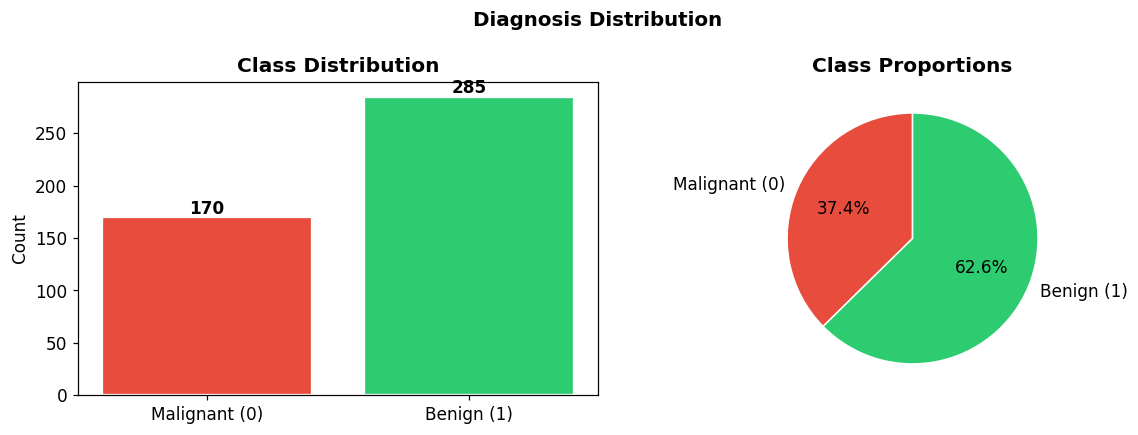

In [13]:
#  Class distribution 
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = train_df[TARGET].value_counts().sort_index()
labels = ['Malignant (0)', 'Benign (1)']
colors = ['#e74c3c', '#2ecc71']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Class Proportions', fontweight='bold')

plt.suptitle('Diagnosis Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

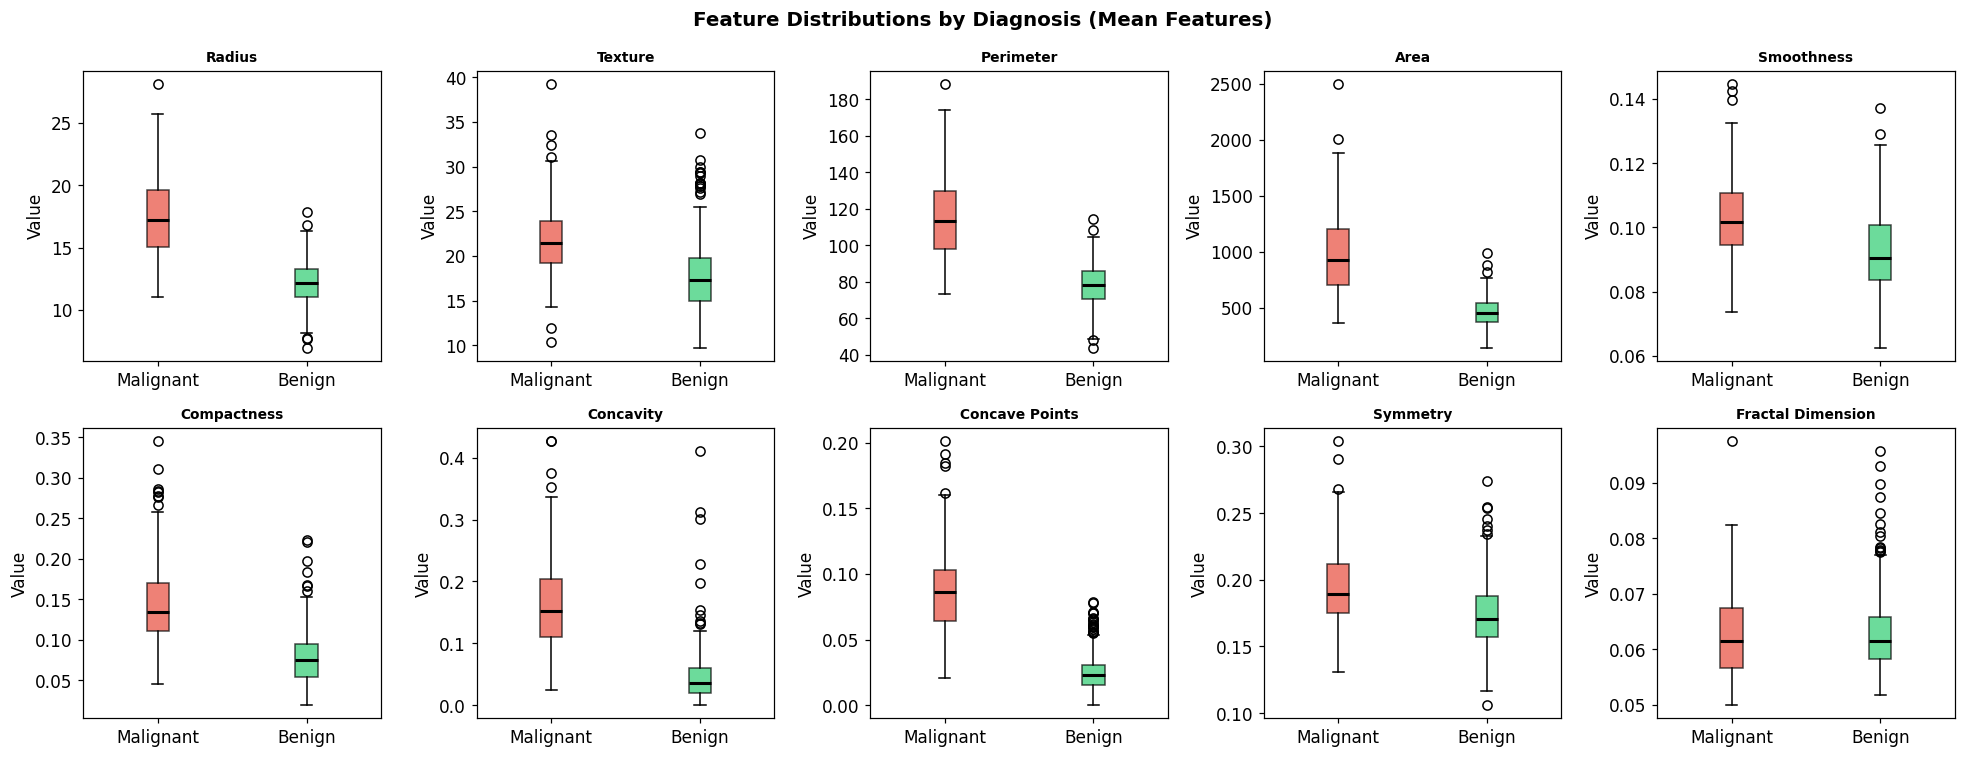

In [14]:
#  Box plots: mean features by diagnosis
# The 10 "mean" features are the most interpretable starting point.
mean_cols = [c for c in train_df.columns if c.startswith('mean_') or 'mean' in c.lower()]
if not mean_cols:  # fallback if columns follow sklearn naming
    mean_cols = [c for c in train_df.columns if c not in [TARGET, ID_COL]][:10]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

class_colors = {0: '#e74c3c', 1: '#2ecc71'}
class_labels = {0: 'Malignant', 1: 'Benign'}

for ax, col in zip(axes, mean_cols[:10]):
    data_by_class = [train_df[train_df[TARGET] == cls][col].dropna()
                     for cls in [0, 1]]
    bp = ax.boxplot(data_by_class, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#e74c3c', '#2ecc71']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Malignant', 'Benign'])
    ax.set_title(col.replace('mean_', '').replace('_', ' ').title(), fontweight='bold', fontsize=9)
    ax.set_ylabel('Value')

plt.suptitle('Feature Distributions by Diagnosis (Mean Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

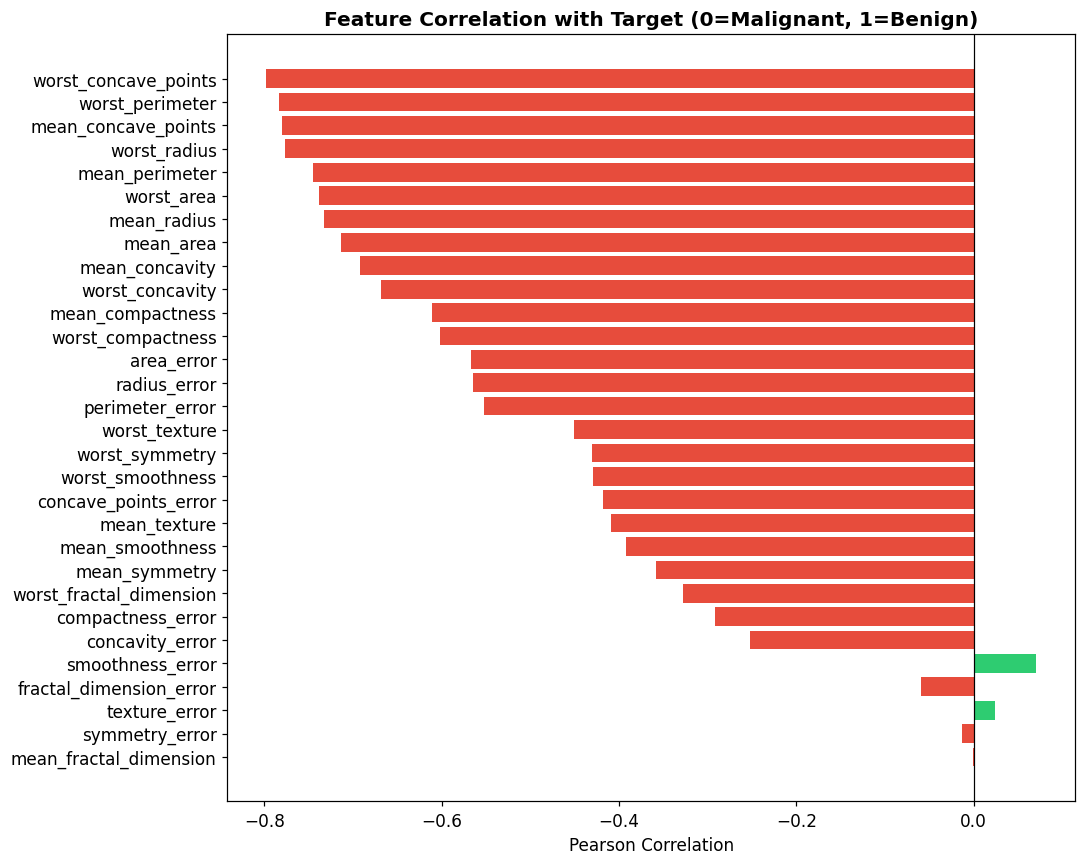

Top 10 positively correlated (more correlated with Benign):
worst_concave_points   -0.798176
worst_perimeter        -0.783376
mean_concave_points    -0.779907
worst_radius           -0.776390
mean_perimeter         -0.745132
worst_area             -0.737965
mean_radius            -0.732224
mean_area              -0.713409
mean_concavity         -0.692052
worst_concavity        -0.668368

Top 10 negatively correlated (more correlated with Malignant):
mean_smoothness           -0.392200
mean_symmetry             -0.358370
worst_fractal_dimension   -0.327308
compactness_error         -0.291239
concavity_error           -0.252785
smoothness_error           0.070507
fractal_dimension_error   -0.059216
texture_error              0.023917
symmetry_error            -0.012765
mean_fractal_dimension    -0.001027


In [15]:
#  Correlation with target 
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in [TARGET, ID_COL]]

corr_with_target = (
    train_df[feature_cols + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 8))
colors_corr = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_target.values]
ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1], color=colors_corr[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Target (0=Malignant, 1=Benign)', fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print("Top 10 positively correlated (more correlated with Benign):")
print(corr_with_target.head(10).to_string())
print("\nTop 10 negatively correlated (more correlated with Malignant):")
print(corr_with_target.tail(10).to_string())

Examples of writing observations:

I observed that:
1. Features like `mean_radius`, `mean_perimeter`, and `mean_area` show a clear separation between malignant and benign tumours (malignant tumours tend to be larger).
2. Negatively correlated features (red bars) are more associated with malignant tumours (class 0).
3. The `worst_*` features tend to be more discriminative than the `mean_*` or `*_error` features.

My plan for preprocessing:
1. All features are numeric, use `StandardScaler` (required for SVM and KNN).
2. No missing values expected, use `SimpleImputer(strategy='median')` as a safety net.
3. No categorical encoding needed.

## Section 3: Preprocessing

Prepare data for modelling:
1. Drop the ID column (not a feature)
2. Separate features (`X`) from target (`y`)
3. Build a preprocessing pipeline (scale + impute)
4. Create a validation split

In [16]:
#  Drop non-feature columns
# id : row identifier, not a feature

DROP_COLS = [ID_COL]

X_all  = train_df.drop(columns=DROP_COLS + [TARGET], errors='ignore').copy()
y_all  = train_df[TARGET].copy()
X_test = test_df.drop(columns=DROP_COLS, errors='ignore').copy()

print(f"Features used : {list(X_all.columns)}")
print(f"\nTrain X shape : {X_all.shape}")
print(f"Test  X shape : {X_test.shape}")

Features used : ['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness', 'mean_compactness', 'mean_concavity', 'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension', 'radius_error', 'texture_error', 'perimeter_error', 'area_error', 'smoothness_error', 'compactness_error', 'concavity_error', 'concave_points_error', 'symmetry_error', 'fractal_dimension_error', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_smoothness', 'worst_compactness', 'worst_concavity', 'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension']

Train X shape : (455, 30)
Test  X shape : (114, 30)


In [17]:
#  Train / validation split 
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.20,
    stratify=y_all,
    random_state=SEED
)
print(f"Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")

Train : 364 | Val : 91 | Test : 114


In [19]:
#  Preprocessing pipeline 
# All breast cancer features are numeric — no categorical branch needed.
# StandardScaler is critical for distance-based models (SVM, KNN).
# SimpleImputer is a safety net in case test data has occasional missing values.

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # safety net: data should be complete
    ('scaler',  StandardScaler()),                   # required for SVM and KNN
])

X_train_proc = preprocessor.fit_transform(X_train)  # ALWAYS fit on training data only
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

print(f"\nProcessed shape: {X_train_proc.shape}")
print("Preprocessing pipeline ready.")

Numeric features (30): ['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness', 'mean_compactness', 'mean_concavity', 'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension', 'radius_error', 'texture_error', 'perimeter_error', 'area_error', 'smoothness_error', 'compactness_error', 'concavity_error', 'concave_points_error', 'symmetry_error', 'fractal_dimension_error', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_smoothness', 'worst_compactness', 'worst_concavity', 'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension']

Processed shape: (364, 30)
Preprocessing pipeline ready.


## Section 4: Baseline Model

**Run this section as-is.** It produces a valid `submission_01.csv` at the baseline F1 ≈ 0.5.

Submit this immediately, it guarantees you a score on the board before you start improving.

In [21]:
# Baseline: DummyClassifier
# Predicts classes at random according to training class frequencies.
# On this dataset (~37% malignant), this gives macro F1 ≈ 0.50.

baseline = DummyClassifier(strategy='stratified', random_state=SEED)  # Initialize DummyClassifier with stratified strategy to predict classes according to training distribution
baseline.fit(X_train_proc, y_train)  # Fit on training data to learn class distribution
y_pred_baseline = baseline.predict(X_val_proc)  # Predict on validation set

# In your exam, you will implement a more sophisticated model here. The DummyClassifier is just a simple baseline to compare against.

In [23]:
f1_baseline = f1_score(y_val, y_pred_baseline, average='macro')  # Calculate macro F1 score on validation set and actual targets

BASELINE DummyClassifier (stratified)
Validation F1 (macro) : 0.5903

              precision    recall  f1-score   support

   Malignant       0.50      0.44      0.47        34
      Benign       0.69      0.74      0.71        57

    accuracy                           0.63        91
   macro avg       0.59      0.59      0.59        91
weighted avg       0.62      0.63      0.62        91



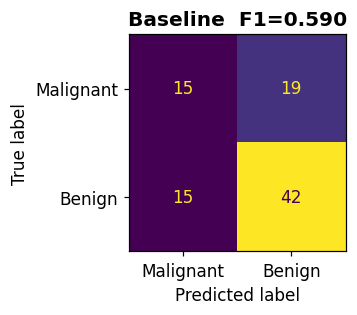

In [24]:
print("=" * 50)
print("BASELINE DummyClassifier (stratified)")
print("=" * 50)
print(f"Validation F1 (macro) : {f1_baseline:.4f}")
print()
print(classification_report(y_val, y_pred_baseline, target_names=['Malignant', 'Benign']))  # Print classification report with precision, recall, F1-score for each class

# To show the Confusion matrix for baseline predictions
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_baseline, ax=ax,
    display_labels=['Malignant', 'Benign'], colorbar=False
)
ax.set_title(f'Baseline  F1={f1_baseline:.3f}', fontweight='bold')
plt.tight_layout()
plt.show()

### Submit your work.
Run this cell every time you want to create a new `submission_{n}.csv`.

**Upload both `submission_{n}.csv` and this notebook to the e-learning platform.**

**Remember to be careful of variable names!**

In [25]:
# STEP 1: Change the file name for each new submission (e.g., submission_01.csv, submission_02.csv).
output_file_name = 'submission_01.csv'

# STEP 2: Refit on ALL labelled data, then predict on test set.
X_all_proc = preprocessor.transform(X_all)  # Ensure you're using the correct names for the full training data!
baseline.fit(X_all_proc, y_all)
y_pred_test_baseline = baseline.predict(X_test_proc)
# You can also use predict_proba and set a custom threshold if you want, but for the baseline we will keep it simple with predict().
# E.g. for predict_proba:
# y_pred_proba = baseline.predict_proba(X_test_proc)[:, 1]
# threshold = 0.5
# y_pred_test_baseline = (y_pred_proba >= threshold).astype(int)

# STEP 3: Build submission dataframe
submission_final = pd.DataFrame({
    ID_COL : test_ids,
    TARGET  : y_pred_test_baseline
})

# STEP 4: Sanity checks
assert len(submission_final) == len(test_ids),        "Row count mismatch!"
assert submission_final[TARGET].isnull().sum() == 0,  "Contains NaN predictions!"
assert set(submission_final[TARGET].unique()).issubset({0, 1}), "Invalid class values!"

# STEP 5: Save to CSV
submission_final.to_csv(output_file_name, index=False)

print(f"{output_file_name} saved — upload this to the e-learning platform now.")
print(f"  Rows : {len(submission_final)}")
print(f"  Predicted malignant rate : {(submission_final[TARGET] == 0).mean():.1%}")
print(f"  Predicted benign rate    : {(submission_final[TARGET] == 1).mean():.1%}")
print()
display(submission_final.head(10))

submission_01.csv saved — upload this to the e-learning platform now.
  Rows : 114
  Predicted malignant rate : 33.3%
  Predicted benign rate    : 66.7%



,id,target
0,257,1
1,429,0
2,502,0
3,364,1
4,565,1
5,465,1
6,359,1
7,344,0
8,517,1
9,568,0



## Section 5: Improve the Baseline (Ideas)

**Steps to improve:**
1. Engineer better features from the raw measurements
2. Try multiple classifiers and compare their F1 scores
3. Tune hyperparameters of the best model

Use the **Appendix** for function signatures and code patterns.

> Add a markdown cell after each step to explain **why** you made each decision.

In [26]:
#  STEP 1: Feature Engineering ─
# Work on copies of the raw dataframes — do NOT overwrite train_df / test_df.

def engineer_features(df):
    """Apply feature engineering to a dataframe. Modify this function."""
    df = df.copy()

    #  Log-transform right-skewed area and perimeter features ─
    # Reduces the influence of extreme outliers on distance-based models.
    for col in ['mean_area', 'area_error', 'worst_area',
                'mean_perimeter', 'perimeter_error', 'worst_perimeter']:
        if col in df.columns:
            df[f'log_{col}'] = np.log1p(df[col])

    #  Mean-to-worst ratios (measures how extreme the worst measurements are)
    # A large ratio suggests the tumour has especially irregular cells.
    for metric in ['radius', 'texture', 'perimeter', 'area']:
        mean_col  = f'mean_{metric}'
        worst_col = f'worst_{metric}'
        if mean_col in df.columns and worst_col in df.columns:
            df[f'{metric}_mean_worst_ratio'] = df[mean_col] / (df[worst_col] + 1e-8)

    #  Compactness × Concavity interaction 
    # Both measure irregular shape; their product amplifies the malignant signal.
    if 'mean_compactness' in df.columns and 'mean_concavity' in df.columns:
        df['compact_x_concavity'] = df['mean_compactness'] * df['mean_concavity']

    #  Sum of worst features (overall "worst case" score) ─
    worst_cols = [c for c in df.columns if c.startswith('worst_')]
    if worst_cols:
        # Standardise before summing so scale differences don't dominate
        worst_vals = df[worst_cols].copy()
        df['worst_feature_sum'] = (
            (worst_vals - worst_vals.mean()) / (worst_vals.std() + 1e-8)
        ).sum(axis=1)

    # 
    # ADD YOUR OWN FEATURES BELOW
    # Ideas:
    #   df['area_per_perimeter'] = df['mean_area'] / (df['mean_perimeter'] + 1e-8)
    #   df['concave_points_ratio'] = df['mean_concave_points'] / (df['worst_concave_points'] + 1e-8)

    return df


# Apply to all splits (work on raw dataframes, not the processed arrays)
train_fe = engineer_features(train_df)
test_fe  = engineer_features(test_df)

DROP_FE = [ID_COL, TARGET]

X_train_fe = train_fe.drop(columns=[c for c in DROP_FE if c in train_fe.columns])
y_train_fe = train_fe[TARGET].copy()
X_test_fe  = test_fe.drop(columns=[c for c in DROP_FE if c in test_fe.columns])

print("Features after engineering:")
print(list(X_train_fe.columns))

Features after engineering:
['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness', 'mean_compactness', 'mean_concavity', 'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension', 'radius_error', 'texture_error', 'perimeter_error', 'area_error', 'smoothness_error', 'compactness_error', 'concavity_error', 'concave_points_error', 'symmetry_error', 'fractal_dimension_error', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_smoothness', 'worst_compactness', 'worst_concavity', 'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension', 'log_mean_area', 'log_area_error', 'log_worst_area', 'log_mean_perimeter', 'log_perimeter_error', 'log_worst_perimeter', 'radius_mean_worst_ratio', 'texture_mean_worst_ratio', 'perimeter_mean_worst_ratio', 'area_mean_worst_ratio', 'compact_x_concavity', 'worst_feature_sum']


In [27]:
#  Rebuild train/val split and preprocessor with engineered features 
X_tr_fe, X_va_fe, y_tr_fe, y_va_fe = train_test_split(
    X_train_fe, y_train_fe,
    test_size=0.20, stratify=y_train_fe, random_state=SEED
)

# All engineered features are numeric — use a single Pipeline
preprocessor_fe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

X_tr_proc      = preprocessor_fe.fit_transform(X_tr_fe)  # fit on training split only
X_va_proc      = preprocessor_fe.transform(X_va_fe)
X_test_proc_fe = preprocessor_fe.transform(X_test_fe)

print(f"Engineered + processed shape: {X_tr_proc.shape}")

Engineered + processed shape: (364, 42)


In [28]:
#  STEP 2: Compare Multiple Models ─
# Quick survey — identify the best starting model before tuning.

candidate_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=5, random_state=SEED),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=SEED),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    'KNN (k=5)'           : KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)'           : SVC(kernel='rbf', probability=True, random_state=SEED),
}

results = []
for name, model in candidate_models.items():
    model.fit(X_tr_proc, y_tr_fe)
    preds = model.predict(X_va_proc)
    f1  = f1_score(y_va_fe, preds, average='macro')
    acc = accuracy_score(y_va_fe, preds)
    results.append({'Model': name, 'Val F1 (macro)': round(f1, 4), 'Val Accuracy': round(acc, 4)})
    print(f"{name:<25}  F1={f1:.4f}  Acc={acc:.4f}")

results_df = pd.DataFrame(results).sort_values('Val F1 (macro)', ascending=False)
print()
print(results_df.to_string(index=False))
best_name = results_df.iloc[0]['Model']
print(f"\nBest model so far: {best_name}")

Logistic Regression        F1=0.9641  Acc=0.9670
Decision Tree              F1=0.9061  Acc=0.9121
Random Forest              F1=0.9416  Acc=0.9451
Gradient Boosting          F1=0.9296  Acc=0.9341
KNN (k=5)                  F1=0.9393  Acc=0.9451
SVM (RBF)                  F1=0.9882  Acc=0.9890

              Model  Val F1 (macro)  Val Accuracy
          SVM (RBF)          0.9882        0.9890
Logistic Regression          0.9641        0.9670
      Random Forest          0.9416        0.9451
          KNN (k=5)          0.9393        0.9451
  Gradient Boosting          0.9296        0.9341
      Decision Tree          0.9061        0.9121

Best model so far: SVM (RBF)


In [29]:
#  STEP 3: Hyperparameter Tuning 
# Tune the best model from the comparison above.
# Replace RandomForestClassifier below with your chosen model if different.
# See Appendix D for parameter grids for other models.

tuned_model = RandomForestClassifier(random_state=SEED)

param_dist = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

search = RandomizedSearchCV(
    estimator=tuned_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    random_state=SEED,
    verbose=0,
)
search.fit(X_tr_proc, y_tr_fe)

print(f"Best CV F1   : {search.best_score_:.4f}")
print(f"Best params  : {search.best_params_}")

best_tuned   = search.best_estimator_
y_pred_tuned = best_tuned.predict(X_va_proc)
f1_tuned     = f1_score(y_va_fe, y_pred_tuned, average='macro')
print(f"\nValidation F1 after tuning : {f1_tuned:.4f}")

Best CV F1   : 0.9647
Best params  : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}

Validation F1 after tuning : 0.9296


YOUR MODEL: Validation F1 (macro): 0.9296

              precision    recall  f1-score   support

   Malignant       0.91      0.91      0.91        34
      Benign       0.95      0.95      0.95        57

    accuracy                           0.93        91
   macro avg       0.93      0.93      0.93        91
weighted avg       0.93      0.93      0.93        91



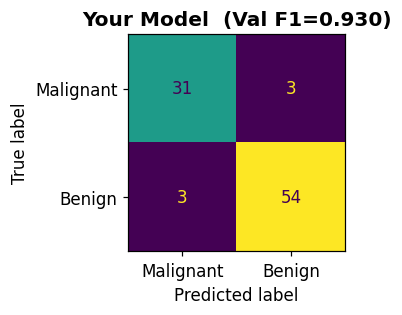

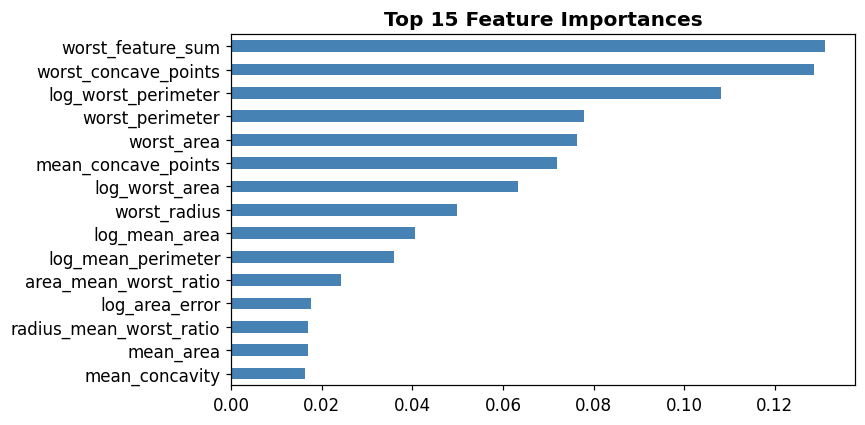

In [44]:
#  Evaluate your best model 
my_best_model = best_tuned  # swap for any model you prefer

y_pred_best = my_best_model.predict(X_va_proc)
f1_best     = f1_score(y_va_fe, y_pred_best, average='macro')

print("=" * 50)
print(f"YOUR MODEL: Validation F1 (macro): {f1_best:.4f}")
print("=" * 50)
print()
print(classification_report(y_va_fe, y_pred_best, target_names=['Malignant', 'Benign']))

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(
    y_va_fe, y_pred_best, ax=ax,
    display_labels=['Malignant', 'Benign'], colorbar=False
)
ax.set_title(f'Your Model  (Val F1={f1_best:.3f})', fontweight='bold')
plt.tight_layout()
plt.show()

# Feature importances (if the model supports it)
if hasattr(my_best_model, 'feature_importances_'):
    feat_names = list(X_tr_fe.columns)
    importance = pd.Series(my_best_model.feature_importances_, index=feat_names)
    top_imp = importance.sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(8, 4))
    top_imp.sort_values().plot.barh(ax=ax, color='steelblue')
    ax.set_title('Top 15 Feature Importances', fontweight='bold')
    plt.tight_layout()
    plt.show()

### Submit your work (you can also submit your work here after feature engineering)
Run this cell every time you want to create a new `submission_{n}.csv`.

**Upload both `submission_{n}.csv` and this notebook to the e-learning platform.**

**Remember to be careful of variable names!**

In [45]:
# STEP 1: Change the file name for each new submission.
output_file_name = 'submission_02.csv'

# STEP 2: Refit on ALL labelled data, then predict on test set.
X_all_fe_proc = preprocessor_fe.fit_transform(X_train_fe)  # Ensure you're using the correct names for the full training data!
X_test_final  = preprocessor_fe.transform(X_test_fe)

my_best_model.fit(X_all_fe_proc, y_train_fe)
y_pred_final = my_best_model.predict(X_test_final)
# You can also use predict_proba and set a custom threshold if you want.
# E.g. for predict_proba:
# y_pred_proba = my_best_model.predict_proba(X_test_final)[:, 1]
# threshold = 0.5
# y_pred_final = (y_pred_proba >= threshold).astype(int)

# STEP 3: Build submission dataframe
submission_final = pd.DataFrame({
    ID_COL : test_ids,
    TARGET  : y_pred_final
})

# STEP 4: Sanity checks
assert len(submission_final) == len(test_ids),        "Row count mismatch!"
assert submission_final[TARGET].isnull().sum() == 0,  "Contains NaN predictions!"
assert set(submission_final[TARGET].unique()).issubset({0, 1}), "Invalid class values!"

# STEP 5: Save to CSV
submission_final.to_csv(output_file_name, index=False)

print(f"{output_file_name} saved, upload this to the e-learning platform now.")
print(f"  Rows : {len(submission_final)}")
print(f"  Predicted malignant rate : {(submission_final[TARGET] == 0).mean():.1%}")
print(f"  Predicted benign rate    : {(submission_final[TARGET] == 1).mean():.1%}")
print()
display(submission_final.head(10))

submission_02.csv saved, upload this to the e-learning platform now.
  Rows : 114
  Predicted malignant rate : 37.7%
  Predicted benign rate    : 62.3%



,id,target
0,257,0
1,429,1
2,502,0
3,364,0
4,565,0
5,465,1
6,359,1
7,344,0
8,517,0
9,568,0


# APPENDIX, Offline Reference

> Read-only reference material. Contains all the sklearn documentation you need, no internet required.

**Sections:** 
[A Models](#app-a) 
[B Preprocessing & Feature Engineering](#app-b) 
[C Metrics](#app-c) 
[D Hyperparameter Tuning](#app-d) 
[E Quick Patterns](#app-e)

<a id='app-a'></a>

## Appendix A: Classification Models

All classifiers share the same interface:
```python
model.fit(X_train, y_train)            # train
model.predict(X_test)                  # hard class predictions
model.predict_proba(X_test)[:, 1]      # probability of class 1 (benign)
model.score(X_test, y_test)            # accuracy
```


### A1: Logistic Regression
Good default. Fast. Interpretable. Needs scaled features.
```python
LogisticRegression(
    C=1.0,               # inverse regularisation: larger = less regularised
    penalty='l2',        # 'l1' (sparse/feature selection), 'l2' (default)
    solver='lbfgs',      # 'liblinear' for l1 or small datasets
    max_iter=1000,       # increase if ConvergenceWarning appears
    class_weight='balanced',  # useful for imbalanced targets
    random_state=42,
)
```


### A2: Decision Tree
Interpretable. Prone to overfitting without `max_depth` constraint.
```python
DecisionTreeClassifier(
    max_depth=5,            # None = grow fully → overfits; try 3–10
    criterion='gini',       # 'gini' or 'entropy'
    min_samples_split=2,    # min samples to split a node
    min_samples_leaf=1,     # min samples in a leaf
    class_weight='balanced',
    random_state=42,
)
```



### A3: Random Forest
Strong all-round model. Hard to overfit. Parallel ensemble of trees.
```python
RandomForestClassifier(
    n_estimators=200,       # number of trees; more is better (but slower)
    max_depth=None,         # constrain to reduce overfitting on small data
    max_features='sqrt',    # features per split: 'sqrt' (default), 'log2', int
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    class_weight='balanced',
    n_jobs=-1,              # use all CPU cores
    random_state=42,
)
```



### A4: Gradient Boosting
Often highest accuracy. Sequential boosting — corrects residuals of previous trees.
```python
GradientBoostingClassifier(
    n_estimators=200,       # boosting rounds
    learning_rate=0.1,      # smaller = more trees needed, but more robust
    max_depth=3,            # keep shallow (3–5)
    subsample=0.8,          # fraction of samples per round (stochastic boosting)
    min_samples_split=2,
    random_state=42,
)
```



### A5: Support Vector Machine (SVM)
Excellent margin-based classifier. Must scale features. Slower on large data.
```python
SVC(
    C=1.0,               # regularisation: larger = harder margin
    kernel='rbf',        # 'linear', 'rbf' (default), 'poly', 'sigmoid'
    gamma='scale',       # 'scale' (1/n_features*var), 'auto', float
    class_weight='balanced',
    probability=True,    # required to use predict_proba()
    random_state=42,
)
```



### A6: K-Nearest Neighbours
No training phase. Sensitive to scale — always scale first.
```python
KNeighborsClassifier(
    n_neighbors=5,       # try odd numbers: 3, 5, 7, 11, 15
    metric='euclidean',  # 'euclidean', 'manhattan', 'minkowski'
    weights='uniform',   # 'uniform' or 'distance' (closer neighbours vote more)
    n_jobs=-1,
)
```



### A7: Handling Class Imbalance
This dataset is imbalanced (~37% malignant). Options:
```python
# Option 1: class_weight parameter (applies to most models)
model = RandomForestClassifier(class_weight='balanced', ...)

# Option 2: compute explicit weights
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
model   = RandomForestClassifier(class_weight={0: weights[0], 1: weights[1]}, ...)

# Option 3: adjust prediction threshold (see Appendix E3)
```

<a id='app-b'></a>

## Appendix B: Preprocessing & Feature Engineering

### B1: Scaling
```python
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

scaler = StandardScaler()              # mean=0, std=1  ← best default
# scaler = MinMaxScaler()             # scale to [0,1], uncomment this line to use this
# scaler = RobustScaler()             # median/IQR, robust to outliers, uncomment this line to use this

X_train_sc = scaler.fit_transform(X_train)  # ALWAYS fit on train only
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
```

### B2: Handling Missing Values (safety net for this dataset)
```python
from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy='median')          # numeric: robust to outliers
# imp = SimpleImputer(strategy='mean')          # numeric: sensitive to outliers
# imp = SimpleImputer(strategy='most_frequent') # categorical
# imp = SimpleImputer(strategy='constant', fill_value=0)

X_train_imp = imp.fit_transform(X_train)
X_test_imp  = imp.transform(X_test)
```

### B3: Breast Cancer Feature Engineering Ideas
```python
# Log-transform right-skewed features (area, perimeter)
for col in ['mean_area', 'area_error', 'worst_area',
            'mean_perimeter', 'perimeter_error', 'worst_perimeter']:
    df[f'log_{col}'] = np.log1p(df[col])

# Mean-to-worst ratio (how extreme the worst measurement is)
for metric in ['radius', 'texture', 'perimeter', 'area']:
    df[f'{metric}_mean_worst_ratio'] = (
        df[f'mean_{metric}'] / (df[f'worst_{metric}'] + 1e-8)
    )

# Compactness × Concavity interaction (shape irregularity signal)
df['compact_x_concavity'] = df['mean_compactness'] * df['mean_concavity']

# Area per perimeter (shape efficiency — circles are most efficient)
df['area_per_perimeter'] = df['mean_area'] / (df['mean_perimeter'] + 1e-8)

# Concave-points ratio (mean vs worst)
df['concave_pts_ratio'] = (
    df['mean_concave_points'] / (df['worst_concave_points'] + 1e-8)
)

# Sum of worst features (overall worst-case severity)
worst_cols = [c for c in df.columns if c.startswith('worst_')]
df['worst_feature_sum'] = df[worst_cols].sum(axis=1)
```

### B4: Feature Selection (useful when you have many correlated features)
```python
from sklearn.feature_selection import SelectKBest, f_classif

# Select top K features by ANOVA F-statistic
selector = SelectKBest(score_func=f_classif, k=15)
X_selected = selector.fit_transform(X_train, y_train)
selected_idx = selector.get_support(indices=True)

# Feature importances from a fitted Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
importance = pd.Series(rf.feature_importances_, index=feature_names) \
               .sort_values(ascending=False)
print(importance.head(15))
```

### B5: Dimensionality Reduction (optional, for highly correlated datasets)
```python
from sklearn.decomposition import PCA

pca = PCA(n_components=10, random_state=42)  # keep top 10 components
X_train_pca = pca.fit_transform(X_train_sc)
X_val_pca   = pca.transform(X_val_sc)
X_test_pca  = pca.transform(X_test_sc)

print(f"Explained variance: {pca.explained_variance_ratio_.cumsum()[-1]:.1%}")
```

<a id='app-c'></a>

## Appendix C: Evaluation Metrics

### C1: The Exam Metric, Macro F1 Score

$$\text{Precision} = \frac{TP}{TP+FP} \qquad \text{Recall} = \frac{TP}{TP+FN} \qquad F_1 = 2 \cdot \frac{P \cdot R}{P + R}$$

**Macro F1** = average F1 across all classes (each class counts equally).
On this dataset (binary): average of F1 for class 0 (Malignant) and F1 for class 1 (Benign).

```python
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred, average='macro')    # ← exam metric
# average='weighted' — weights by class support
# average='binary'   — only positive class
```

### C2: Full Metrics Reference
```python
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision : {precision_score(y_true, y_pred, average='macro'):.4f}")
print(f"Recall    : {recall_score(y_true, y_pred, average='macro'):.4f}")
print(f"F1 (macro): {f1_score(y_true, y_pred, average='macro'):.4f}")

# Full per-class breakdown
print(classification_report(y_true, y_pred, target_names=['Malignant', 'Benign']))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, display_labels=['Malignant', 'Benign']
).plot()

# ROC-AUC (needs probabilities)
y_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_true, y_proba)
```

### C3: Cross-Validation
```python
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    estimator=model,
    X=X_all_proc,
    y=y_all,
    cv=cv,
    scoring='f1_macro',   # matches exam metric
    n_jobs=-1
)
print(f"CV F1: {scores.mean():.4f} ± {scores.std():.4f}")

# Available scoring strings:
# 'f1_macro', 'f1_weighted', 'f1_micro', 'f1'
# 'accuracy', 'roc_auc', 'precision_macro', 'recall_macro'
```

<a id='app-d'></a>

## Appendix D: Hyperparameter Tuning

### D1: RandomizedSearchCV (recommended in exam, much faster)
```python
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions={
        'n_estimators'     : [100, 200, 300, 500],
        'max_depth'        : [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf' : [1, 2, 4],
        'max_features'     : ['sqrt', 'log2'],
    },
    n_iter=20,              # random combinations to try; 20–50 is practical
    scoring='f1_macro',     # ← always use exam metric here
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42,
)
search.fit(X_train, y_train)
best_model = search.best_estimator_
print(search.best_params_, search.best_score_)
```

### D2: GridSearchCV (exhaustive, use for small grids)
```python
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1','l2'],
                'solver': ['liblinear']},
    scoring='f1_macro', cv=5, n_jobs=-1
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
```

### D3: Parameter Grids for All Models
```python
# Logistic Regression
lr_params = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
             'penalty': ['l1','l2'], 'solver': ['liblinear']}

# Decision Tree
dt_params = {'max_depth': [3, 5, 7, 10, None],
             'min_samples_split': [2, 5, 10, 20],
             'criterion': ['gini', 'entropy']}

# Random Forest
rf_params = {'n_estimators': [100, 200, 300],
             'max_depth': [5, 10, 20, None],
             'min_samples_split': [2, 5, 10],
             'max_features': ['sqrt', 'log2']}

# Gradient Boosting
gb_params = {'n_estimators': [100, 200, 300],
             'learning_rate': [0.01, 0.05, 0.1, 0.2],
             'max_depth': [2, 3, 4, 5],
             'subsample': [0.7, 0.8, 1.0]}

# SVM
svm_params = {'C': [0.1, 1, 10, 100],
              'kernel': ['rbf', 'linear'],
              'gamma': ['scale', 'auto', 0.01, 0.1]}

# KNN
knn_params = {'n_neighbors': [3, 5, 7, 11, 15, 21],
              'weights': ['uniform', 'distance'],
              'metric': ['euclidean', 'manhattan']}
```

<a id='app-e'></a>

## Appendix E: Quick Code Patterns

### E1: Drop-in Model Swap
```python
# Replace this block with any model from Appendix A:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                    max_depth=4, random_state=42)
model.fit(X_tr_proc, y_tr_fe)
preds = model.predict(X_va_proc)
print(f"GBM F1: {f1_score(y_va_fe, preds, average='macro'):.4f}")
print(classification_report(y_va_fe, preds, target_names=['Malignant', 'Benign']))
```

### E2: Full sklearn Pipeline
Chains preprocessing + model so you never accidentally leak validation data.
```python
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   RandomForestClassifier(n_estimators=200, random_state=42)),
])
pipe.fit(X_train, y_train)
preds = pipe.predict(X_val)
```

### E3: Threshold Tuning
By default classifiers predict class 1 when `P(class=1) >= 0.5`.
For medical data, lowering the threshold catches more malignant cases (higher recall for class 0).
```python
y_proba  = model.predict_proba(X_val)[:, 1]   # probability of benign (class 1)

best_thresh, best_f1 = 0.5, 0.0
for t in np.arange(0.2, 0.8, 0.05):
    preds  = (y_proba >= t).astype(int)
    score  = f1_score(y_val, preds, average='macro')
    if score > best_f1:
        best_f1, best_thresh = score, t

print(f"Best threshold: {best_thresh:.2f}  F1: {best_f1:.4f}")
y_pred_final = (model.predict_proba(X_test)[:, 1] >= best_thresh).astype(int)
```

### E4: Save Submission & Sanity Check
```python
submission = pd.DataFrame({'id': test_ids, 'target': y_pred_final})
submission.to_csv('submission_XX.csv', index=False)

# Quick checks
s = pd.read_csv('submission_XX.csv')
assert len(s) == len(test_ids)
assert s['target'].isnull().sum() == 0
assert set(s['target'].unique()).issubset({0, 1})
print("Valid submission!")
print(s['target'].value_counts())
```

### E5: Quick Visualisations
```python
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred, display_labels=['Malignant', 'Benign']
).plot()

# ROC curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model, X_val, y_val).plot()

# Feature importances (tree-based models)
pd.Series(model.feature_importances_, index=feature_names) \
  .sort_values(ascending=False).head(15).plot.barh()
plt.title('Feature Importances')
plt.show()

# Correlation heatmap (top correlated features)
top_feats = corr_with_target.abs().sort_values(ascending=False).head(12).index.tolist()
sns.heatmap(train_df[top_feats + ['target']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation: Top Features vs Target')
plt.show()
```